# Challenge 1: datos y análisis exploratorio

Tu primera responsabilidad es preparar una fuente de datos confiable para el proyecto de clasificación de vinos.

**Entrada:** `data/raw/wine.csv`  
**Salidas:** `data/processed/train.csv`, `data/processed/test.csv` y `artifacts/data_contract.json`

> El conjunto de test se crea aquí, pero no debe explorarse ni utilizarse después del split.

## Objetivos

- cargar y validar datos externos;
- identificar problemas básicos de calidad;
- crear un split reproducible y estratificado;
- realizar EDA únicamente sobre entrenamiento;
- guardar datos y metadatos para la siguiente etapa.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in (PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga y profiling

In [3]:
DATA_PATH = RAW_DATA_DIR / "wine.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
print("Forma:", df.shape)
print("Duplicados:", df.duplicated().sum())
print("Valores faltantes:", int(df.isna().sum().sum()))
print("\nDistribucion de target:")
print(df["target"].value_counts().sort_index())
print("\nProporcion:")
print(df["target"].value_counts(normalize=True).sort_index().round(3))

profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
    "min": df.min(numeric_only=True),
    "max": df.max(numeric_only=True),
})
profile

Forma: (178, 14)
Duplicados: 0
Valores faltantes: 0

Distribucion de target:
target
0    59
1    71
2    48
Name: count, dtype: int64

Proporcion:
target
0    0.331
1    0.399
2    0.270
Name: proportion, dtype: float64


,dtype,missing,unique,min,max
alcohol,float64,0,126,11.03,14.83
malic_acid,float64,0,133,0.74,5.80
ash,float64,0,79,1.36,3.23
alcalinity_of_ash,float64,0,63,10.60,30.00
magnesium,float64,0,53,70.00,162.00
total_phenols,float64,0,97,0.98,3.88
flavanoids,float64,0,132,0.34,5.08
nonflavanoid_phenols,float64,0,39,0.13,0.66
proanthocyanins,float64,0,101,0.41,3.58
color_intensity,float64,0,132,1.28,13.00


**Conclusión de calidad:**

> El archivo tiene 178 vinos, 13 variables numéricas (todas float) y la columna `target` con 3 clases. No encontré valores faltantes ni filas duplicadas, y los mínimos y máximos se ven razonables, así que no fue necesario borrar ni corregir nada. Las clases están un poco desbalanceadas (40 % la clase 1, 33 % la clase 0 y 27 % la clase 2), por eso decidí hacer el split estratificado. Lo que sí se nota es que las escalas son muy distintas, por ejemplo `proline` llega a 1680 y `hue` está alrededor de 1, entonces para modelos como regresión logística y KNN toca estandarizar dentro del pipeline.

## 2. Split train/test

In [5]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["target"],
    random_state=RANDOM_STATE,
)

print("Proporcion de clases en train:")
print(train_df["target"].value_counts(normalize=True).sort_index().round(3))
print("Proporcion de clases en test:")
print(test_df["target"].value_counts(normalize=True).sort_index().round(3))

Proporcion de clases en train:
target
0    0.331
1    0.401
2    0.268
Name: proportion, dtype: float64
Proporcion de clases en test:
target
0    0.333
1    0.389
2    0.278
Name: proportion, dtype: float64


In [6]:
# Verificación del split
assert len(train_df) + len(test_df) == len(df)
assert set(train_df.index).isdisjoint(set(test_df.index))
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (142, 14)
Test: (36, 14)


## 3. EDA sobre entrenamiento

Incluye:

- distribución de clases;
- distribuciones o boxplots de variables relevantes;
- correlaciones;
- tres hallazgos que puedan influir en el modelado.

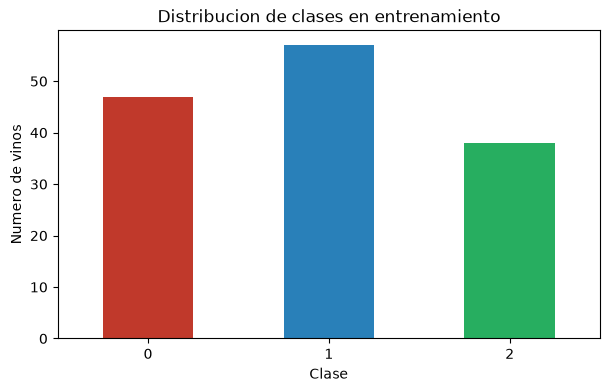

,mean,std,min,max
proline,739.478873,301.499014,278.00,1515.00
magnesium,99.633803,14.937448,70.00,162.00
alcalinity_of_ash,19.625352,3.380848,10.60,30.00
color_intensity,4.989648,2.334947,1.28,13.00
malic_acid,2.340000,1.101285,0.74,5.80
flavanoids,1.985352,0.951952,0.34,3.74
alcohol,12.971479,0.802521,11.03,14.83
od280/od315_of_diluted_wines,2.606197,0.689650,1.27,3.92
total_phenols,2.273732,0.621454,0.98,3.88
proanthocyanins,1.600211,0.579777,0.42,3.58


In [7]:
counts = train_df["target"].value_counts().sort_index()
ax = counts.plot.bar(color=["#c0392b", "#2980b9", "#27ae60"])
ax.set_xlabel("Clase")
ax.set_ylabel("Numero de vinos")
ax.set_title("Distribucion de clases en entrenamiento")
plt.xticks(rotation=0)
plt.show()

train_df.drop(columns="target").describe().T[["mean", "std", "min", "max"]].sort_values("std", ascending=False)

flavanoids                      0.870
od280/od315_of_diluted_wines    0.784
total_phenols                   0.714
proline                         0.639
hue                             0.606
alcalinity_of_ash               0.508
proanthocyanins                 0.481
nonflavanoid_phenols            0.477
malic_acid                      0.418
alcohol                         0.332
color_intensity                 0.269
magnesium                       0.208
ash                             0.045
Name: target, dtype: float64


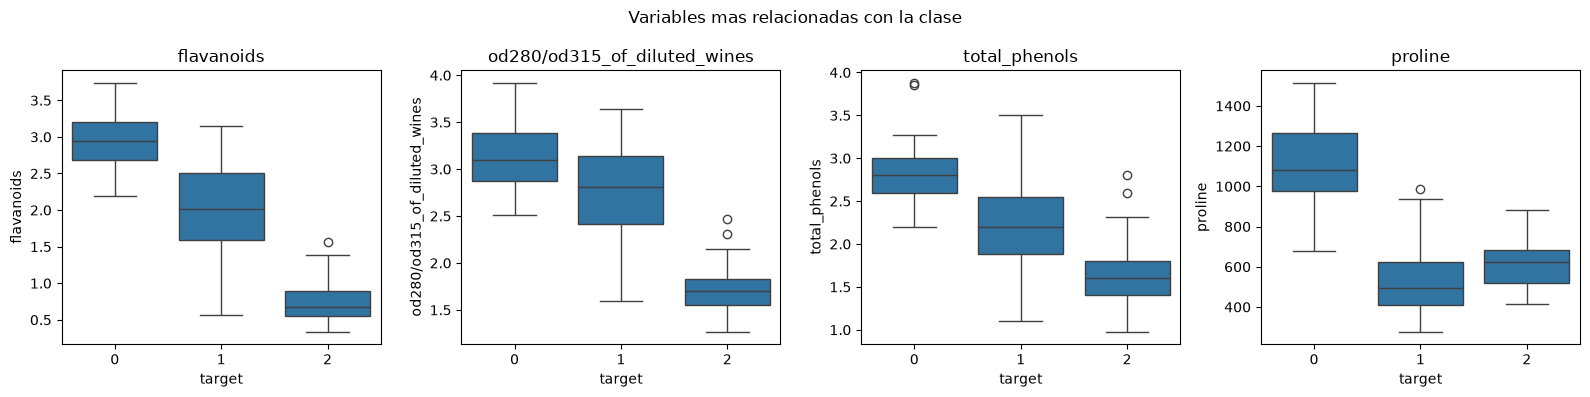

In [8]:
correlations = train_df.corr(numeric_only=True)["target"].drop("target").abs().sort_values(ascending=False)
print(correlations.round(3))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, correlations.index[:4]):
    sns.boxplot(data=train_df, x="target", y=col, ax=ax)
    ax.set_title(col)
plt.suptitle("Variables mas relacionadas con la clase")
plt.tight_layout()
plt.show()

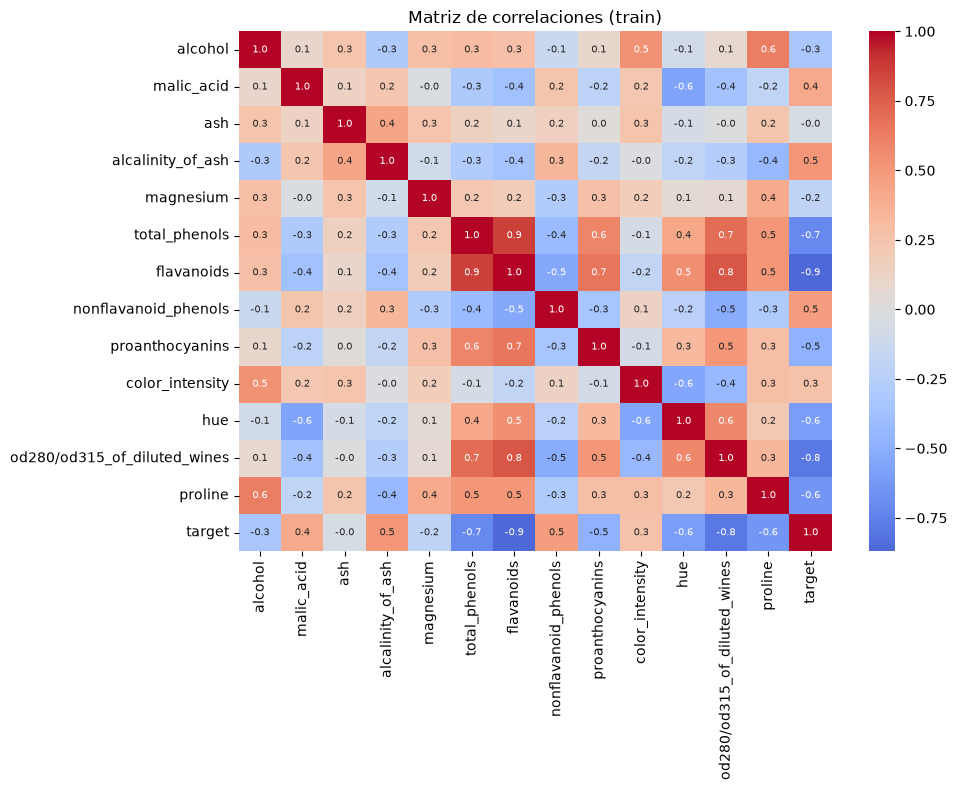

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_df.corr(numeric_only=True), cmap="coolwarm", center=0, annot=True, fmt=".1f", annot_kws={"size": 7})
plt.title("Matriz de correlaciones (train)")
plt.tight_layout()
plt.show()

**Hallazgos:**

1. Las variables con más relación con la clase son `flavanoids` (0.87 de correlación absoluta con target), `od280/od315_of_diluted_wines` (0.78), `total_phenols` (0.71) y `proline` (0.64). En los boxplots se ve que `flavanoids` separa casi perfecto las tres clases: la clase 0 tiene valores altos, la 1 intermedios y la 2 muy bajos. `proline` sirve sobre todo para separar la clase 0 de las otras dos. Con variables así, espero que hasta un modelo lineal funcione muy bien.
2. Las escalas son muy diferentes entre variables (`proline` tiene desviación de 301 y `nonflavanoid_phenols` de 0.12). Para regresión logística y KNN hay que usar `StandardScaler`, si no `proline` dominaría las distancias de KNN. El árbol no lo necesita.
3. Hay variables muy correlacionadas entre ellas, por ejemplo `total_phenols` con `flavanoids` (0.9) y `flavanoids` con `od280/od315` (0.8). Esto no impide entrenar, pero quiere decir que hay información repetida y que hay que tener cuidado al interpretar los coeficientes. Además el dataset es muy pequeño (142 vinos en train), así que conviene usar validación cruzada estratificada para que los resultados no dependan de un solo split.

## 4. Persistencia de datos y contrato

In [10]:
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.to_csv(PROCESSED_DATA_DIR / "train.csv", index=False)
test_df.to_csv(PROCESSED_DATA_DIR / "test.csv", index=False)

feature_names = df.drop(columns="target").columns.tolist()

contract = {
    "dataset": "Wine",
    "target": "target",
    "target_names": ["class_0", "class_1", "class_2"],
    "features": feature_names,
    "random_state": RANDOM_STATE,
    "test_size": 0.20,
}

(ARTIFACTS_DIR / "data_contract.json").write_text(json.dumps(contract, indent=2), encoding="utf-8")
print("Datos y contrato guardados.")

Datos y contrato guardados.


In [11]:
# Verificación de entrega
assert (PROCESSED_DATA_DIR / "train.csv").exists()
assert (PROCESSED_DATA_DIR / "test.csv").exists()
assert (ARTIFACTS_DIR / "data_contract.json").exists()
print("Challenge 1 completado.")

Challenge 1 completado.


## Checklist

- [x] Cargué el CSV desde `data/raw`.
- [x] Revisé calidad y distribución de la clase.
- [x] Realicé un split estratificado.
- [x] No exploré el conjunto de test.
- [x] Guardé los tres artefactos requeridos.